In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(X_train.shape, X_test.shape)

(16000, 49) (4000, 49)


In [2]:
# A reusable evaluation function
# Since I'll run the same evaluation for every model 
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    print(f'--- {name} ---')
    print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}')
    print(f'Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}')
    print(f'F1-Score:  {f1_score(y_test, y_pred, zero_division=0):.4f}')
    if y_proba is not None:
        print(f'ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud'], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    return {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }

--- Logistic Regression ---
Accuracy:  0.9848
Precision: 0.6522
Recall:    0.2206
F1-Score:  0.3297
ROC-AUC:   0.9493

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      3932
       Fraud       0.65      0.22      0.33        68

    accuracy                           0.98      4000
   macro avg       0.82      0.61      0.66      4000
weighted avg       0.98      0.98      0.98      4000



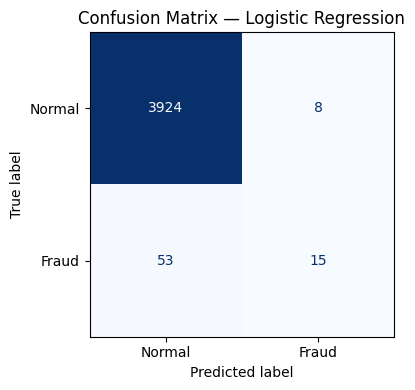

In [3]:
#Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
results_lr = evaluate_model('Logistic Regression', log_reg, X_test, y_test)

--- Decision Tree ---
Accuracy:  0.9725
Precision: 0.2083
Recall:    0.2206
F1-Score:  0.2143
ROC-AUC:   0.6030

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      3932
       Fraud       0.21      0.22      0.21        68

    accuracy                           0.97      4000
   macro avg       0.60      0.60      0.60      4000
weighted avg       0.97      0.97      0.97      4000



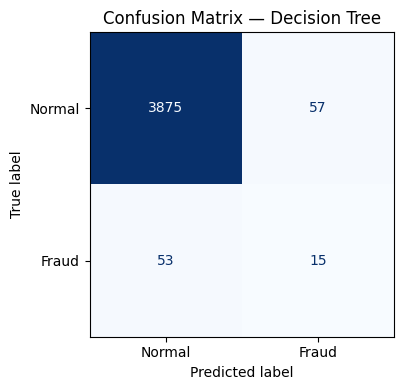

In [4]:
#Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
results_dt = evaluate_model('Decision Tree', dt, X_test, y_test)

--- KNN ---
Accuracy:  0.9830
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.5717

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      3932
       Fraud       0.00      0.00      0.00        68

    accuracy                           0.98      4000
   macro avg       0.49      0.50      0.50      4000
weighted avg       0.97      0.98      0.97      4000



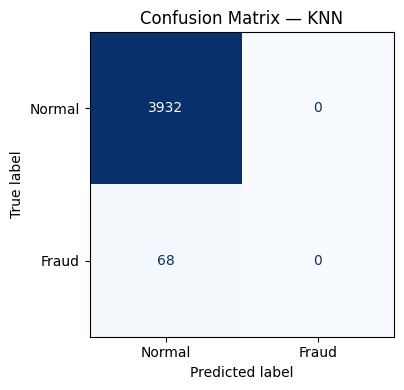

In [5]:
#K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
results_knn = evaluate_model('KNN', knn, X_test, y_test)

--- SVM (RBF) ---
Accuracy:  0.9830
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.8994

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      3932
       Fraud       0.00      0.00      0.00        68

    accuracy                           0.98      4000
   macro avg       0.49      0.50      0.50      4000
weighted avg       0.97      0.98      0.97      4000



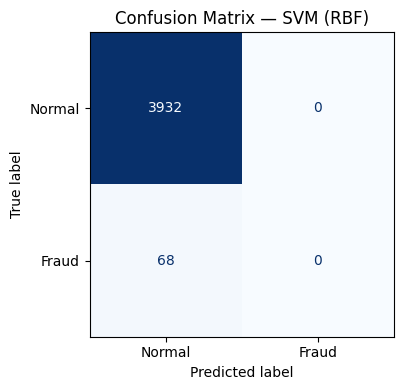

In [6]:
#SVM
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)
results_svm = evaluate_model('SVM (RBF)', svm, X_test, y_test)

In [7]:
#comparison table of all the models
results_df = pd.DataFrame([results_lr, results_dt, results_knn, results_svm])
results_df = results_df.sort_values('f1', ascending=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.98475,0.652174,0.220588,0.329670,0.949304
1,Decision Tree,0.97250,0.208333,0.220588,0.214286,0.603046
2,KNN,0.98300,0.000000,0.000000,0.000000,0.571745
3,SVM (RBF),0.98300,0.000000,0.000000,0.000000,0.899449
